# ushape vs kusabi: T1/T3 Power Plot 解説ノートブック

このノートブックでは `kusabi_T1_T3_power_plot.py` と `ushape_T1_T3_power_plot.py` の
2つの本質的な違いを可視化しながら解説します。

1. **スタッガードグリッドとノードの種類**
2. **形状パラメータ（mn_〜）の意味と配置**
3. **`cut_top_map` の構築ロジックの違い**
4. **T5境界補正（ushapeのみ）の必要性と仕組み**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, Rectangle, FancyBboxPatch

plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

---
## 1. スタッガードグリッドとノードの種類

シミュレーションは**スタッガードグリッド**（互い違いに配置されたグリッド）を使います。
配列のインデックスと物理的な位置の関係を以下に示します。

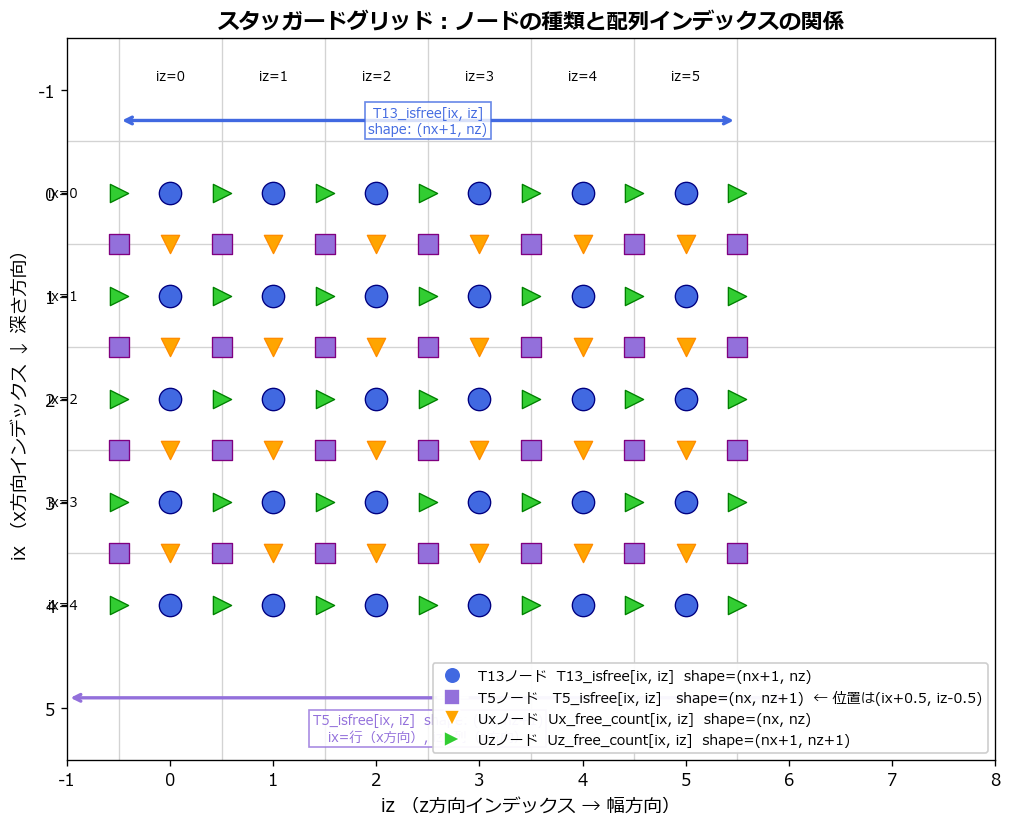

● = T13  ■ = T5  ▼ = Ux  ▶ = Uz


In [5]:
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_aspect('equal')
ax.set_xlim(-1, 8)
ax.set_ylim(5.5, -1.5)

NX_demo = 4
NZ_demo = 6

# --- グリッド線 ---
for iz in range(NZ_demo + 1):
    ax.axvline(iz - 0.5, color='lightgray', lw=0.8, zorder=0)
for ix in range(NX_demo + 1):
    ax.axhline(ix - 0.5, color='lightgray', lw=0.8, zorder=0)

# --- T13ノード（整数格子点）●青 ---
for ix in range(NX_demo + 1):
    for iz in range(NZ_demo):
        ax.scatter(iz, ix, s=180, c='royalblue', marker='o', zorder=3, edgecolors='navy', linewidths=0.8)

# --- T5ノード（x+0.5の位置）■紫 ---
for ix in range(NX_demo):
    for iz in range(NZ_demo + 1):
        ax.scatter(iz - 0.5, ix + 0.5, s=140, c='mediumpurple', marker='s', zorder=3, edgecolors='purple', linewidths=0.8)

# --- Uxノード（セル中心）▼オレンジ ---
for ix in range(NX_demo):
    for iz in range(NZ_demo):
        ax.scatter(iz, ix + 0.5, s=120, c='orange', marker='v', zorder=3, edgecolors='darkorange', linewidths=0.8)

# --- Uzノード（▷緑）---
for ix in range(NX_demo + 1):
    for iz in range(NZ_demo + 1):
        ax.scatter(iz - 0.5, ix, s=120, c='limegreen', marker='>', zorder=3, edgecolors='green', linewidths=0.8)

# --- インデックスラベル（一部） ---
for iz in range(NZ_demo):
    ax.text(iz, -1.2, f'iz={iz}', ha='center', va='top', fontsize=8, color='black')
for ix in range(NX_demo + 1):
    ax.text(-0.9, ix, f'ix={ix}', ha='right', va='center', fontsize=8, color='black')

# --- T13の配列サイズ注釈 ---
ax.annotate('', xy=(NZ_demo - 0.5, -0.7), xytext=(-0.5, -0.7),
            arrowprops=dict(arrowstyle='<->', color='royalblue', lw=2))
ax.text((NZ_demo-1)/2, -0.55, 'T13_isfree[ix, iz]\nshape: (nx+1, nz)', ha='center', va='bottom',
        fontsize=8, color='royalblue',
        bbox=dict(fc='white', ec='royalblue', alpha=0.8, pad=2))

# --- T5の配列サイズ注釈 ---
ax.annotate('', xy=(NZ_demo - 0.5 + 0.5, NX_demo + 0.5 + 0.4), xytext=(-0.5 - 0.5, NX_demo + 0.5 + 0.4),
            arrowprops=dict(arrowstyle='<->', color='mediumpurple', lw=2))
ax.text((NZ_demo - 1)/2, NX_demo + 0.5 + 0.55, 'T5_isfree[ix, iz]  shape: (nx, nz+1)\nix=行（x方向）, iz=列（z方向）',
        ha='center', va='top', fontsize=8, color='mediumpurple',
        bbox=dict(fc='white', ec='mediumpurple', alpha=0.8, pad=2))

# --- 軸ラベル ---
ax.set_xlabel('iz （z方向インデックス → 幅方向）', fontsize=11)
ax.set_ylabel('ix （x方向インデックス ↓ 深さ方向）', fontsize=11)
ax.set_title('スタッガードグリッド：ノードの種類と配列インデックスの関係', fontsize=13, fontweight='bold')

# --- 凡例 ---
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='royalblue', markersize=10,
           label='T13ノード  T13_isfree[ix, iz]  shape=(nx+1, nz)'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='mediumpurple', markersize=10,
           label='T5ノード   T5_isfree[ix, iz]   shape=(nx, nz+1)  ← 位置は(ix+0.5, iz-0.5)'),
    Line2D([0],[0], marker='v', color='w', markerfacecolor='orange', markersize=10,
           label='Uxノード  Ux_free_count[ix, iz]  shape=(nx, nz)'),
    Line2D([0],[0], marker='>', color='w', markerfacecolor='limegreen', markersize=10,
           label='Uzノード  Uz_free_count[ix, iz]  shape=(nx+1, nz+1)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8.5, framealpha=0.95)

plt.tight_layout()
plt.savefig('node_layout.png', dpi=150, bbox_inches='tight')
plt.show()
print('● = T13  ■ = T5  ▼ = Ux  ▶ = Uz')

**ポイント**
- `T13_isfree[ix, iz]` : x方向の整数格子点。配列サイズは **(nx+1, nz)**
- `T5_isfree[ix, iz]`  : x方向の中間点（位置は ix+0.5）。配列サイズは **(nx, nz+1)**
- `=1` → 固体（有効）、`=0` → 空洞（穴の中）
- ix が増える方向 = **深さ方向（下）**、iz が増える方向 = **幅方向（右）**

---
## 2. 形状パラメータ（mn_〜）の意味と配置

### 2-A：kusabi（くさび形）のパラメータ

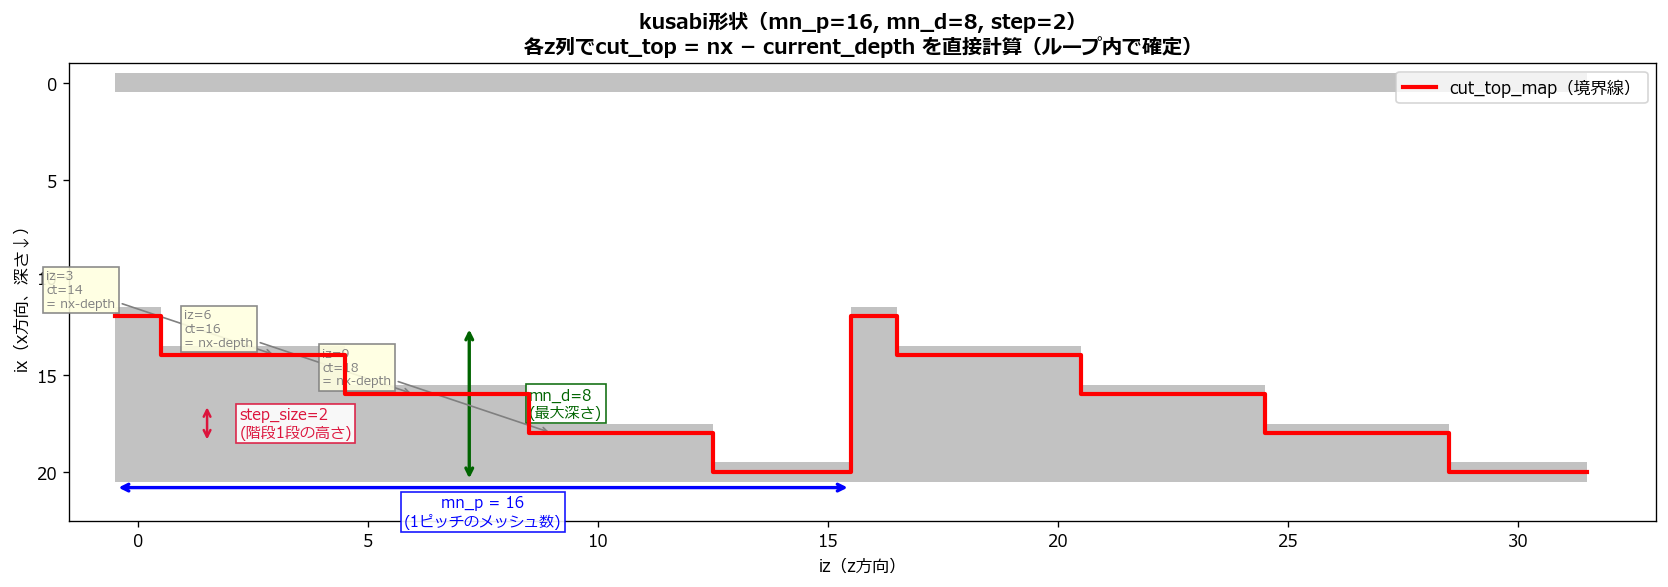

In [6]:
# --- kusabi パラメータ（小さめにして図を見やすく）---
mn_p_k = 16   # ピッチ（メッシュ数）
mn_d_k = 8    # 深さ（メッシュ数）
step_size_k = 2
NX_k = 20
NZ_k = mn_p_k * 2

T13_k = np.ones((NX_k + 1, NZ_k))
cut_top_k = np.full(NZ_k, NX_k)

T13_k[0, :] = 0
T13_k[NX_k, :] = 0

for i in range(int(np.ceil(NZ_k / mn_p_k))):
    z_start = i * mn_p_k
    z_end   = min((i+1)*mn_p_k, NZ_k)
    for z in range(z_start, z_end):
        local_z = z - z_start
        ideal_depth = mn_d_k * (1.0 - local_z / mn_p_k)
        current_depth = (int(ideal_depth) // step_size_k) * step_size_k
        if current_depth > 0:
            ct = NX_k - current_depth
            T13_k[ct:NX_k+1, z] = 0
            cut_top_k[z] = ct
        else:
            cut_top_k[z] = NX_k

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_aspect('equal')

# T13マップ（灰=空洞、白=固体）
disp = (T13_k == 0).astype(float)  # 0=solid white, 1=void gray
ax.imshow(disp, cmap='Greys', vmin=0, vmax=1.5, aspect='auto',
          extent=[-0.5, NZ_k-0.5, NX_k+0.5, -0.5], origin='upper', alpha=0.4)

# 境界線
lz, lx = [], []
for iz in range(NZ_k):
    c = cut_top_k[iz]
    if not lz:
        lz += [iz-0.5, iz+0.5]; lx += [c, c]
    else:
        if lx[-1] != c:
            lz += [iz-0.5, iz-0.5, iz+0.5]; lx += [lx[-1], c, c]
        else:
            lz.append(iz+0.5); lx.append(c)
ax.plot(lz, lx, 'r-', lw=2.5, label='cut_top_map（境界線）', zorder=5)

# パラメータ注釈
# mn_p
ax.annotate('', xy=(mn_p_k - 0.5, NX_k + 0.8), xytext=(-0.5, NX_k + 0.8),
            arrowprops=dict(arrowstyle='<->', color='blue', lw=2))
ax.text(mn_p_k/2 - 0.5, NX_k + 1.2, f'mn_p = {mn_p_k}\n(1ピッチのメッシュ数)',
        ha='center', va='top', color='blue', fontsize=9,
        bbox=dict(fc='white', ec='blue', alpha=0.9, pad=2))

# mn_d
ax.annotate('', xy=(7.2, NX_k + 0.5), xytext=(7.2, NX_k - mn_d_k + 0.5),
            arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=2))
ax.text(8.5, NX_k - mn_d_k/2 + 0.5, f'mn_d={mn_d_k}\n(最大深さ)',
        ha='left', va='center', color='darkgreen', fontsize=9,
        bbox=dict(fc='white', ec='darkgreen', alpha=0.9, pad=2))

# step_size
ax.annotate('', xy=(1.5, NX_k - 2*step_size_k + 0.5), xytext=(1.5, NX_k - step_size_k + 0.5),
            arrowprops=dict(arrowstyle='<->', color='crimson', lw=1.5))
ax.text(2.2, NX_k - 1.5*step_size_k + 0.5, f'step_size={step_size_k}\n(階段1段の高さ)',
        ha='left', va='center', color='crimson', fontsize=9,
        bbox=dict(fc='white', ec='crimson', alpha=0.9, pad=2))

# 「各z列でcut_topを直接計算」矢印
for iz in [3, 6, 9]:
    ct = cut_top_k[iz]
    if ct < NX_k:
        ax.annotate(f'iz={iz}\nct={ct}\n= nx-depth',
                    xy=(iz, ct), xytext=(iz - 5, ct - 2.5),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1),
                    fontsize=7.5, color='gray',
                    bbox=dict(fc='lightyellow', ec='gray', alpha=0.9, pad=2))

ax.set_xlim(-1.5, NZ_k + 1)
ax.set_ylim(NX_k + 2.5, -1)
ax.set_xlabel('iz（z方向）', fontsize=10)
ax.set_ylabel('ix（x方向、深さ↓）', fontsize=10)
ax.set_title(f'kusabi形状（mn_p={mn_p_k}, mn_d={mn_d_k}, step={step_size_k}）\n'
             r'各z列でcut_top = nx − current_depth を直接計算（ループ内で確定）',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

**kusabiのポイント**

各z列の深さは `ideal_depth = mn_d × (1 − local_z / mn_p)` という**1本の式**で決まります。
階段化すると `current_depth = floor(ideal_depth / step_size) × step_size` となり、
`cut_top = nx − current_depth` も**式で一発計算**できます。

→ T13設定と `cut_top_map` 更新を**同じループ内で同時に**行える。

### 2-B：ushape（U字形）のパラメータ

In [7]:
# --- ushape パラメータ ---
mn_w_u = 9    # 幅（奇数にする）
mn_d_u = 10   # 深さ
mn_p_u = 25   # ピッチ
step_size_u = 1
NX_u = 20
NZ_u = mn_p_u * 2

mn_r_u = mn_w_u // 2           # 半円の半径
mn_straight_u = mn_d_u - mn_r_u  # 矩形部の高さ
mn_nf_u = max(0, mn_p_u - 2*mn_w_u)  # 隙間
mn_period_u = mn_w_u + mn_nf_u       # 繰り返し周期

print(f'mn_w        = {mn_w_u}  （穴の幅、奇数に調整）')
print(f'mn_d        = {mn_d_u}  （穴の深さ）')
print(f'mn_r        = mn_w//2 = {mn_r_u}  （底部半円の半径）')
print(f'mn_straight = mn_d - mn_r = {mn_straight_u}  （矩形部の高さ）')
print(f'mn_p        = {mn_p_u}  （ピッチ）')
print(f'mn_nf       = mn_p - 2*mn_w = {mn_nf_u}  （穴と穴の隙間）')
print(f'mn_period   = mn_w + mn_nf = {mn_period_u}  （繰り返し周期）')

mn_w        = 9  （穴の幅、奇数に調整）
mn_d        = 10  （穴の深さ）
mn_r        = mn_w//2 = 4  （底部半円の半径）
mn_straight = mn_d - mn_r = 6  （矩形部の高さ）
mn_p        = 25  （ピッチ）
mn_nf       = mn_p - 2*mn_w = 7  （穴と穴の隙間）
mn_period   = mn_w + mn_nf = 16  （繰り返し周期）


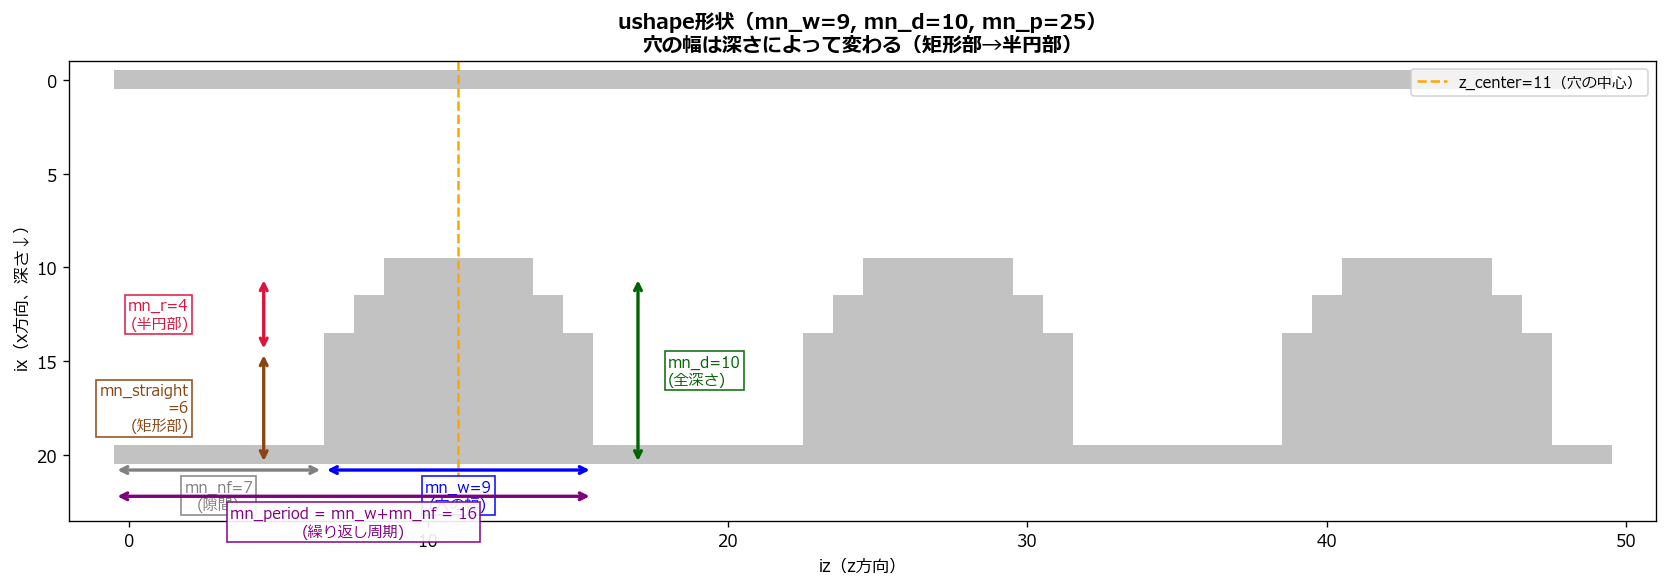

In [8]:
def make_ushape_T13(NX, NZ, mn_w, mn_d, mn_p, step_size):
    mn_r = mn_w // 2
    mn_straight = mn_d - mn_r
    mn_nf = max(0, mn_p - 2*mn_w)
    mn_period = mn_w + mn_nf
    T13 = np.ones((NX+1, NZ))
    T13[0, :] = 0; T13[NX, :] = 0
    num_f = int(np.ceil(NZ / mn_period)) + 1
    for i in range(num_f):
        z_s = i * mn_period + mn_nf
        if z_s >= NZ: break
        z_e = min(z_s + mn_w, NZ)
        z_center = (z_s + z_e) // 2
        for d in range(mn_d):
            xi = (NX-1) - d
            if xi < 0: break
            d_step = (d // step_size) * step_size
            if d_step < mn_straight:
                width_at_d = mn_w
            else:
                arc_d = d_step - mn_straight
                if arc_d < mn_r:
                    half_w_float = np.sqrt(mn_r**2 - arc_d**2)
                    width_at_d = int(half_w_float * 2)
                else:
                    width_at_d = 0
            if width_at_d > 0 and width_at_d % 2 == 0:
                width_at_d -= 1
            if width_at_d < 0: width_at_d = 0
            half = width_at_d // 2
            zl = max(z_center - half, 0)
            zr = min(z_center + half + 1, NZ)
            if zl < zr:
                T13[xi, zl:zr] = 0
                if xi+1 < NX+1:
                    T13[xi+1, zl:zr] = 0
    return T13, mn_r, mn_straight, mn_nf, mn_period

T13_u, mn_r_u, mn_straight_u, mn_nf_u, mn_period_u = make_ushape_T13(
    NX_u, NZ_u, mn_w_u, mn_d_u, mn_p_u, step_size_u)

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_aspect('equal')

disp_u = (T13_u == 0).astype(float)
ax.imshow(disp_u, cmap='Greys', vmin=0, vmax=1.5, aspect='auto',
          extent=[-0.5, NZ_u-0.5, NX_u+0.5, -0.5], origin='upper', alpha=0.4)

# 1ピッチ目の穴の位置
z_s0 = mn_nf_u
z_e0 = z_s0 + mn_w_u
z_center0 = (z_s0 + z_e0) // 2

# mn_w アノテーション
ax.annotate('', xy=(z_e0-0.5, NX_u + 0.8), xytext=(z_s0-0.5, NX_u + 0.8),
            arrowprops=dict(arrowstyle='<->', color='blue', lw=2))
ax.text(z_center0, NX_u + 1.3, f'mn_w={mn_w_u}\n(穴の幅)', ha='center', va='top',
        color='blue', fontsize=9, bbox=dict(fc='white', ec='blue', alpha=0.9, pad=2))

# mn_nf アノテーション
ax.annotate('', xy=(z_s0-0.5, NX_u + 0.8), xytext=(-0.5, NX_u + 0.8),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=2))
ax.text(z_s0/2 - 0.5, NX_u + 1.3, f'mn_nf={mn_nf_u}\n(隙間)', ha='center', va='top',
        color='gray', fontsize=9, bbox=dict(fc='white', ec='gray', alpha=0.9, pad=2))

# mn_period アノテーション
ax.annotate('', xy=(mn_period_u - 0.5, NX_u + 2.2), xytext=(-0.5, NX_u + 2.2),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
ax.text(mn_period_u/2 - 0.5, NX_u + 2.7, f'mn_period = mn_w+mn_nf = {mn_period_u}\n(繰り返し周期)',
        ha='center', va='top', color='purple', fontsize=9,
        bbox=dict(fc='white', ec='purple', alpha=0.9, pad=2))

# mn_d / mn_straight / mn_r アノテーション
ax.annotate('', xy=(z_center0 + 6, NX_u + 0.5), xytext=(z_center0 + 6, NX_u - mn_d_u + 0.5),
            arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=2))
ax.text(z_center0 + 7, NX_u - mn_d_u/2 + 0.5, f'mn_d={mn_d_u}\n(全深さ)',
        ha='left', va='center', color='darkgreen', fontsize=9,
        bbox=dict(fc='white', ec='darkgreen', alpha=0.9, pad=2))

ax.annotate('', xy=(z_center0 - 6.5, NX_u + 0.5), xytext=(z_center0 - 6.5, NX_u - mn_straight_u + 0.5),
            arrowprops=dict(arrowstyle='<->', color='saddlebrown', lw=2))
ax.text(z_center0 - 9, NX_u - mn_straight_u/2 + 0.5, f'mn_straight\n={mn_straight_u}\n(矩形部)',
        ha='right', va='center', color='saddlebrown', fontsize=9,
        bbox=dict(fc='white', ec='saddlebrown', alpha=0.9, pad=2))

ax.annotate('', xy=(z_center0 - 6.5, NX_u - mn_straight_u + 0.5),
            xytext=(z_center0 - 6.5, NX_u - mn_d_u + 0.5),
            arrowprops=dict(arrowstyle='<->', color='crimson', lw=2))
ax.text(z_center0 - 9, NX_u - mn_straight_u - mn_r_u/2 + 0.5, f'mn_r={mn_r_u}\n(半円部)',
        ha='right', va='center', color='crimson', fontsize=9,
        bbox=dict(fc='white', ec='crimson', alpha=0.9, pad=2))

# z_center ライン
ax.axvline(z_center0, color='orange', lw=1.5, ls='--', label=f'z_center={z_center0}（穴の中心）')

ax.set_xlim(-2, NZ_u + 1)
ax.set_ylim(NX_u + 3.5, -1)
ax.set_xlabel('iz（z方向）', fontsize=10)
ax.set_ylabel('ix（x方向、深さ↓）', fontsize=10)
ax.set_title(f'ushape形状（mn_w={mn_w_u}, mn_d={mn_d_u}, mn_p={mn_p_u}）\n'
             '穴の幅は深さによって変わる（矩形部→半円部）', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

---
## 3. cut_top_mapの構築ロジックの違い

### `cut_top_map[iz]` とは？

> z列 `iz` において、**固体から空洞に変わる最初のxインデックス**。境界線描画に使う。

kusabiとushapeで、このマップの**作り方が根本的に異なります。**

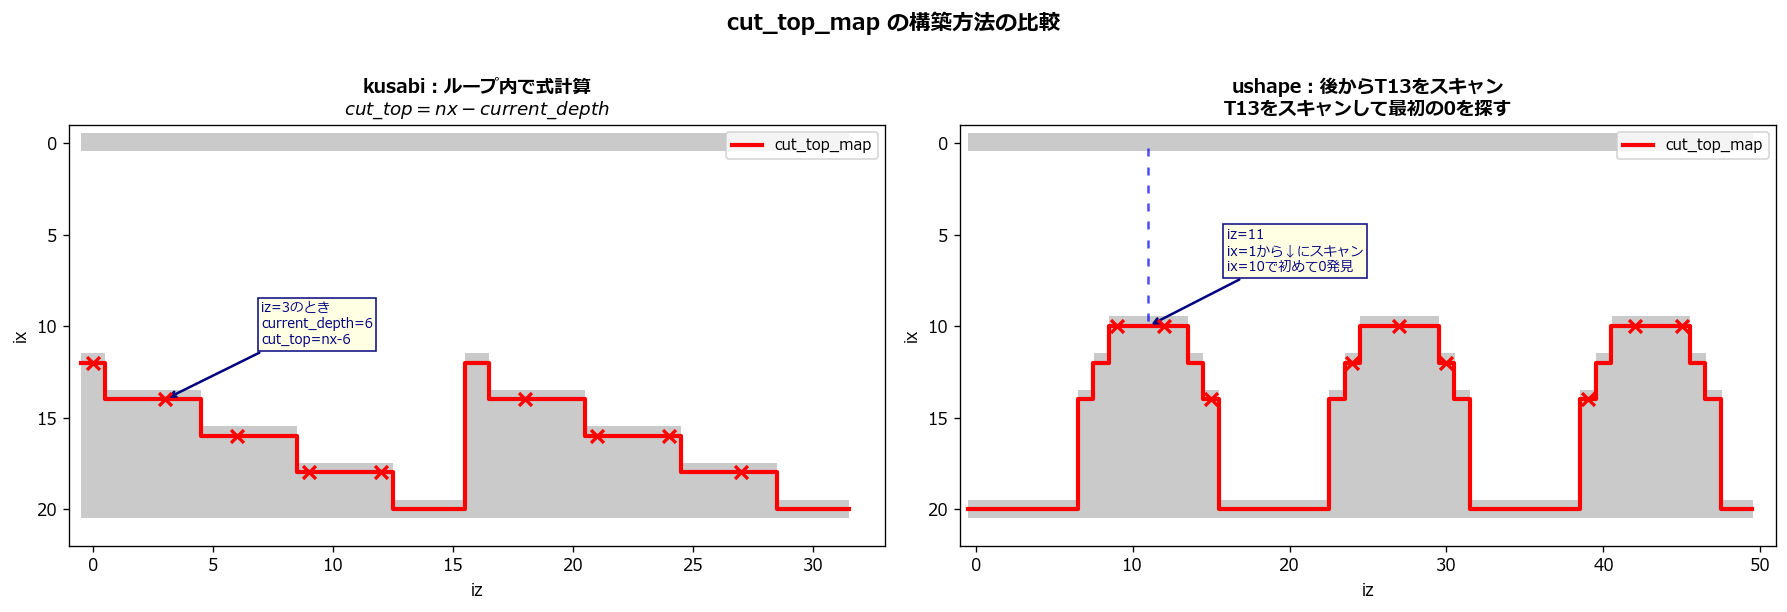

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, title, T13, cut_top, NX, NZ, label in [
    (axes[0], 'kusabi：ループ内で式計算', T13_k, cut_top_k, NX_k, NZ_k,
     r'$cut\_top = nx - current\_depth$'),
    (axes[1], 'ushape：後からT13をスキャン', T13_u,
     None, NX_u, NZ_u, 'T13をスキャンして最初の0を探す')
]:
    # cut_top_map 計算
    if cut_top is None:
        ct_map = np.full(NZ, NX)
        for iz in range(NZ):
            for ix in range(1, NX+1):
                if T13[ix, iz] == 0:
                    ct_map[iz] = ix
                    break
    else:
        ct_map = cut_top

    disp = (T13 == 0).astype(float)
    ax.imshow(disp, cmap='Greys', vmin=0, vmax=1.5, aspect='auto',
              extent=[-0.5, NZ-0.5, NX+0.5, -0.5], origin='upper', alpha=0.35)

    # cut_top_map の値を各列に示す
    show_every = 3
    for iz in range(0, NZ, show_every):
        ct = ct_map[iz]
        if ct < NX:
            ax.scatter(iz, ct, s=60, c='red', zorder=5, marker='x', linewidths=2)

    # 境界線
    lz, lx = [], []
    for iz in range(NZ):
        c = ct_map[iz]
        if not lz:
            lz += [iz-0.5, iz+0.5]; lx += [c, c]
        else:
            if lx[-1] != c:
                lz += [iz-0.5, iz-0.5, iz+0.5]; lx += [lx[-1], c, c]
            else:
                lz.append(iz+0.5); lx.append(c)
    ax.plot(lz, lx, 'r-', lw=2.5, label='cut_top_map')

    ax.set_xlim(-1, NZ + 1)
    ax.set_ylim(NX + 2, -1)
    ax.set_xlabel('iz', fontsize=10)
    ax.set_ylabel('ix', fontsize=10)
    ax.set_title(f'{title}\n{label}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

# kusabi側に「直接計算」の矢印注釈
axes[0].annotate('iz=3のとき\ncurrent_depth=6\ncut_top=nx-6',
                 xy=(3, cut_top_k[3]), xytext=(7, cut_top_k[3] - 3),
                 arrowprops=dict(arrowstyle='->', color='navy', lw=1.5),
                 fontsize=8, color='navy',
                 bbox=dict(fc='lightyellow', ec='navy', alpha=0.9, pad=2))

# ushape側にスキャンの矢印注釈
iz_ex = mn_nf_u + mn_w_u // 2
ct_ex_u = None
for ix in range(1, NX_u+1):
    if T13_u[ix, iz_ex] == 0:
        ct_ex_u = ix; break
if ct_ex_u:
    for ix in range(1, ct_ex_u + 1):
        axes[1].scatter(iz_ex, ix - 0.5, s=25, c='blue', marker='|', zorder=4, alpha=0.7)
    axes[1].annotate(f'iz={iz_ex}\nix=1から↓にスキャン\nix={ct_ex_u}で初めて0発見',
                     xy=(iz_ex, ct_ex_u), xytext=(iz_ex + 5, ct_ex_u - 3),
                     arrowprops=dict(arrowstyle='->', color='navy', lw=1.5),
                     fontsize=8, color='navy',
                     bbox=dict(fc='lightyellow', ec='navy', alpha=0.9, pad=2))

plt.suptitle('cut_top_map の構築方法の比較', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**なぜushapeではスキャンが必要か？**

ushapeのメインループは **x方向（深さd）でループ** しながら、各深さで `width_at_d` を計算してT13に書き込みます。
穴の左右端（zl, zr）は深さによって変わるため、「あるiz列に対してcut_topが何か」は**全深さの書き込みが終わるまで確定しません**。

さらに、後述のT5境界補正によってT13の状態が変わる可能性があるため、**補正後のT13をスキャン**して求めます。

---
## 4. T5境界補正（ushapeのみ）

### T5ノードの位置とT13ノードとの関係

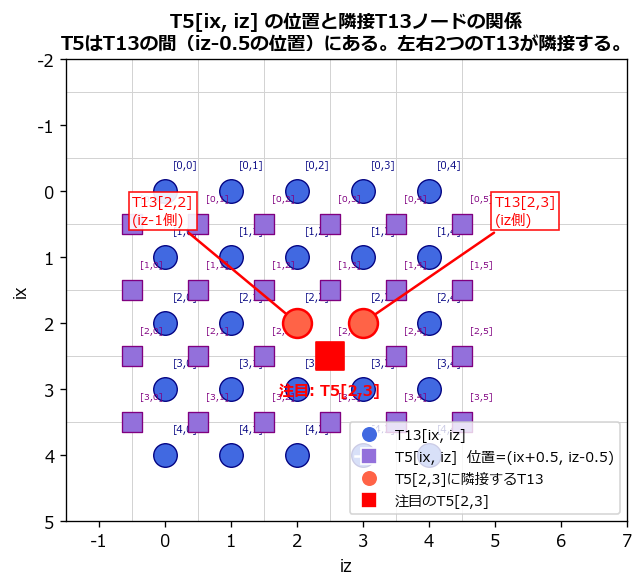

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_aspect('equal')
ax.set_xlim(-1.5, 7)
ax.set_ylim(5, -2)

NX_s, NZ_s = 4, 5

# グリッド線
for iz in range(-1, NZ_s+1):
    ax.axvline(iz - 0.5, color='lightgray', lw=0.6)
for ix in range(-1, NX_s+1):
    ax.axhline(ix - 0.5, color='lightgray', lw=0.6)

# T13ノード
for ix in range(NX_s+1):
    for iz in range(NZ_s):
        ax.scatter(iz, ix, s=200, c='royalblue', marker='o', zorder=3, edgecolors='navy', lw=0.8)
        ax.text(iz + 0.12, ix - 0.35, f'[{ix},{iz}]', fontsize=6, color='navy')

# T5ノード
for ix in range(NX_s):
    for iz in range(NZ_s+1):
        ax.scatter(iz - 0.5, ix + 0.5, s=150, c='mediumpurple', marker='s', zorder=3,
                   edgecolors='purple', lw=0.8)
        ax.text(iz - 0.5 + 0.12, ix + 0.5 - 0.35, f'[{ix},{iz}]', fontsize=5.5, color='purple')

# T5[2,3] に注目して周囲のT13を強調
ix_t5, iz_t5 = 2, 3
ax.scatter(iz_t5 - 0.5, ix_t5 + 0.5, s=300, c='red', marker='s', zorder=5)
ax.text(iz_t5 - 0.5, ix_t5 + 0.5 + 0.6, f'注目: T5[{ix_t5},{iz_t5}]', ha='center',
        fontsize=9, color='red', fontweight='bold')

# 隣接T13に矢印
for iz_adj, label, pos in [(iz_t5-1, f'T13[{ix_t5},{iz_t5-1}]\n(iz-1側)', 'left'),
                            (iz_t5,   f'T13[{ix_t5},{iz_t5}]\n(iz側)', 'right')]:
    ax.scatter(iz_adj, ix_t5, s=300, c='tomato', marker='o', zorder=4, edgecolors='red', lw=1.5)
    ax.annotate(label, xy=(iz_adj, ix_t5),
                xytext=(iz_adj + (2 if pos=='right' else -2.5), ix_t5 - 1.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=8.5, color='red',
                bbox=dict(fc='white', ec='red', alpha=0.9, pad=2))

ax.set_xlabel('iz', fontsize=10)
ax.set_ylabel('ix', fontsize=10)
ax.set_title('T5[ix, iz] の位置と隣接T13ノードの関係\n'
             'T5はT13の間（iz-0.5の位置）にある。左右2つのT13が隣接する。', fontsize=11, fontweight='bold')

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='royalblue', markersize=10, label='T13[ix, iz]'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='mediumpurple', markersize=10, label='T5[ix, iz]  位置=(ix+0.5, iz-0.5)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato', markersize=10, label='T5[2,3]に隣接するT13'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='red', markersize=10, label='注目のT5[2,3]'),
]
ax.legend(handles=legend_elements, fontsize=8.5, loc='lower right')
plt.tight_layout()
plt.show()

**T5補正のルール：**
```
T5[ix, iz] の隣には T13[ix, iz-1]（左）と T13[ix, iz]（右）がある。
どちらか一方でも空洞(=0)なら → T5[ix, iz] も空洞(=0) にする。
```

### なぜushapeではT5とT13が不整合になるか？

不整合セル数（補正前）: 9 個
補正によって新たにvoidになったT5セル数: 9 個


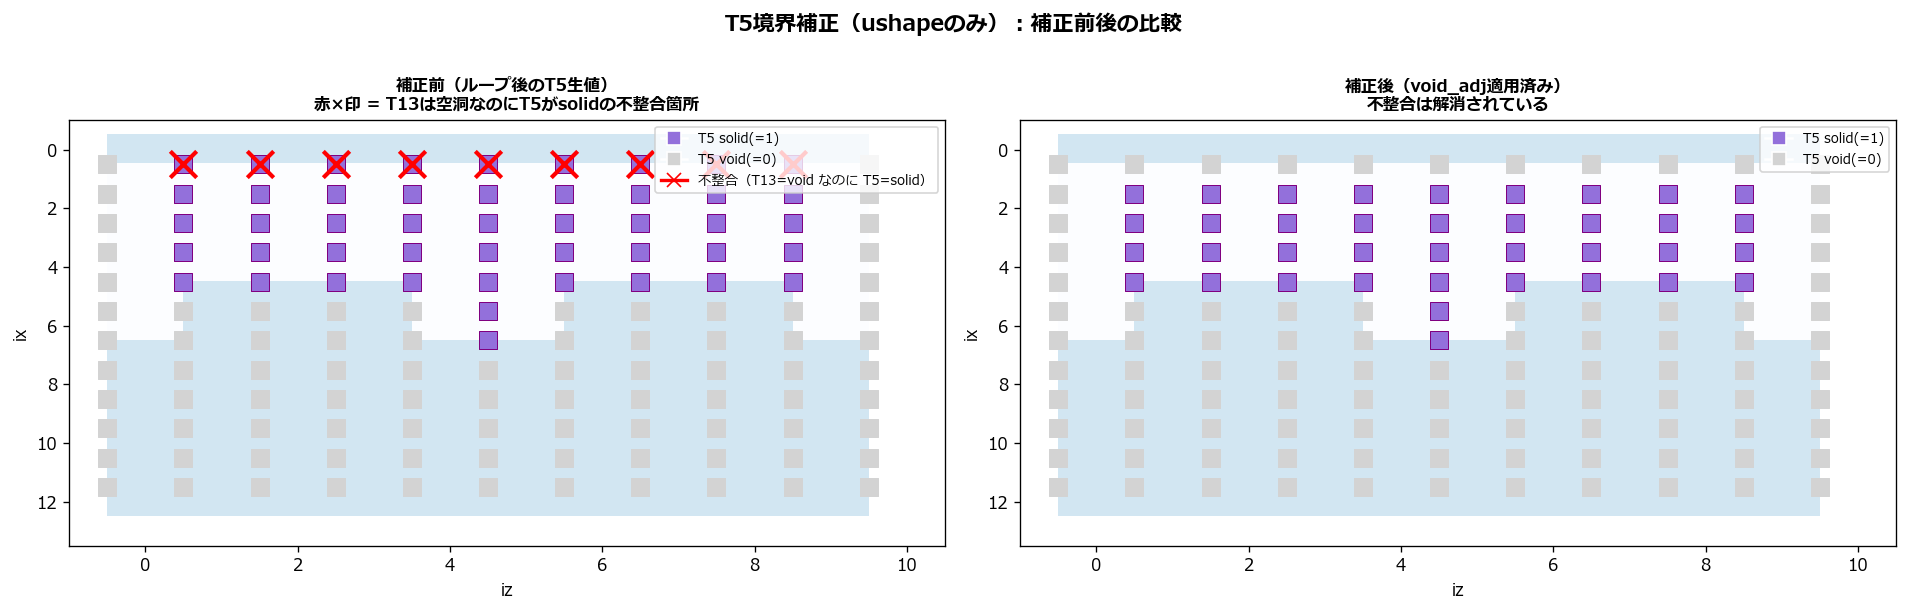

In [11]:
# 小さなushapeでT5補正前後の不整合を可視化
mn_w_s = 5
mn_d_s = 7
mn_p_s = 10
step_s = 1
NX_s2 = 12
NZ_s2 = mn_p_s

def make_ushape_full(NX, NZ, mn_w, mn_d, mn_p, step_size, with_correction=True):
    mn_w_loc = mn_w
    if mn_w_loc % 2 == 0: mn_w_loc -= 1
    mn_r = mn_w_loc // 2
    mn_straight = mn_d - mn_r
    mn_nf = max(0, mn_p - 2*mn_w_loc)
    mn_period = mn_w_loc + mn_nf

    T13 = np.ones((NX+1, NZ))
    T5  = np.ones((NX, NZ+1))
    T13[0, :] = 0; T13[NX, :] = 0
    T5[:, 0] = 0;  T5[:, NZ] = 0

    num_f = int(np.ceil(NZ / mn_period)) + 1
    for i in range(num_f):
        z_s = i * mn_period + mn_nf
        if z_s >= NZ: break
        z_e = min(z_s + mn_w_loc, NZ)
        z_center = (z_s + z_e) // 2
        for d in range(mn_d):
            xi = (NX-1) - d
            if xi < 0: break
            d_step = (d // step_size) * step_size
            if d_step < mn_straight:
                width_at_d = mn_w_loc
            else:
                arc_d = d_step - mn_straight
                if arc_d < mn_r:
                    width_at_d = int(np.sqrt(mn_r**2 - arc_d**2) * 2)
                else:
                    width_at_d = 0
            if width_at_d > 0 and width_at_d % 2 == 0: width_at_d -= 1
            if width_at_d < 0: width_at_d = 0
            half = width_at_d // 2
            zl = max(z_center - half, 0)
            zr = min(z_center + half + 1, NZ)
            if zl < zr:
                T5[xi, zl:zr+1] = 0
                if xi < NX+1:   T13[xi,   zl:zr] = 0
                if xi+1 < NX+1: T13[xi+1, zl:zr] = 0

    T5_before = T5.copy()

    if with_correction:
        void_adj = np.zeros((NX, NZ+1), dtype=bool)
        void_adj[:, 1:]  |= (T13[:NX, :] == 0)
        void_adj[:, :NZ] |= (T13[:NX, :] == 0)
        T5[void_adj] = 0

    return T13, T5, T5_before

T13_s, T5_after, T5_before = make_ushape_full(NX_s2, NZ_s2, mn_w_s, mn_d_s, mn_p_s, step_s, True)

# 不整合セル（T13が空洞なのにT5がsolidのまま）の検出
# T5[ix, iz] の隣 T13[ix, iz-1] または T13[ix, iz] が0なのに T5_before が1
incoherent = np.zeros((NX_s2, NZ_s2+1), dtype=bool)
incoherent[:, 1:]  |= (T13_s[:NX_s2, :] == 0)
incoherent[:, :NZ_s2] |= (T13_s[:NX_s2, :] == 0)
incoherent &= (T5_before == 1)  # 補正前にsolidのまま

print(f'不整合セル数（補正前）: {incoherent.sum()} 個')
print(f'補正によって新たにvoidになったT5セル数: {(T5_before == 1).sum() - (T5_after == 1).sum()} 個')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, T5_plot, ttl, show_incoherent in [
    (axes[0], T5_before, '補正前（ループ後のT5生値）\n赤×印 = T13は空洞なのにT5がsolidの不整合箇所', True),
    (axes[1], T5_after,  '補正後（void_adj適用済み）\n不整合は解消されている', False)
]:
    # T13をグレーで表示
    ax.imshow((T13_s == 0).astype(float), cmap='Blues', vmin=0, vmax=2, aspect='auto',
              extent=[-0.5, NZ_s2-0.5, NX_s2+0.5, -0.5], origin='upper', alpha=0.3)

    # T5をオーバーレイ
    for ix in range(NX_s2):
        for iz in range(NZ_s2+1):
            c = 'mediumpurple' if T5_plot[ix, iz] == 1 else 'lightgray'
            ax.scatter(iz - 0.5, ix + 0.5, s=120, c=c, marker='s', zorder=3,
                       edgecolors='purple' if T5_plot[ix, iz] == 1 else 'lightgray', lw=0.6)

    if show_incoherent:
        ixs, izs = np.where(incoherent)
        for ix, iz in zip(ixs, izs):
            ax.scatter(iz - 0.5, ix + 0.5, s=250, c='red', marker='x', zorder=5, linewidths=2.5)

    ax.set_xlim(-1, NZ_s2 + 0.5)
    ax.set_ylim(NX_s2 + 1.5, -1)
    ax.set_xlabel('iz', fontsize=10)
    ax.set_ylabel('ix', fontsize=10)
    ax.set_title(ttl, fontsize=10, fontweight='bold')

    legend_elements = [
        Line2D([0],[0], marker='s', color='w', markerfacecolor='mediumpurple', markersize=8, label='T5 solid(=1)'),
        Line2D([0],[0], marker='s', color='w', markerfacecolor='lightgray', markersize=8, label='T5 void(=0)'),
    ]
    if show_incoherent:
        legend_elements.append(Line2D([0],[0], marker='x', color='red', markersize=8,
                                      lw=2, label='不整合（T13=void なのに T5=solid）'))
    ax.legend(handles=legend_elements, fontsize=8, loc='upper right')

plt.suptitle('T5境界補正（ushapeのみ）：補正前後の比較', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### T5境界補正のコードを詳解

c:\Users\cs16\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12364 (\N{HIRAGANA LETTER GA}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\cs16\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\cs16\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27934 (\N{CJK UNIFIED IDEOGRAPH-6D1E}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\cs16\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\cs16\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12425 (\N{HIRAGANA LETTER RA}) missing from font(s) DejaVu Sans Mono.
 

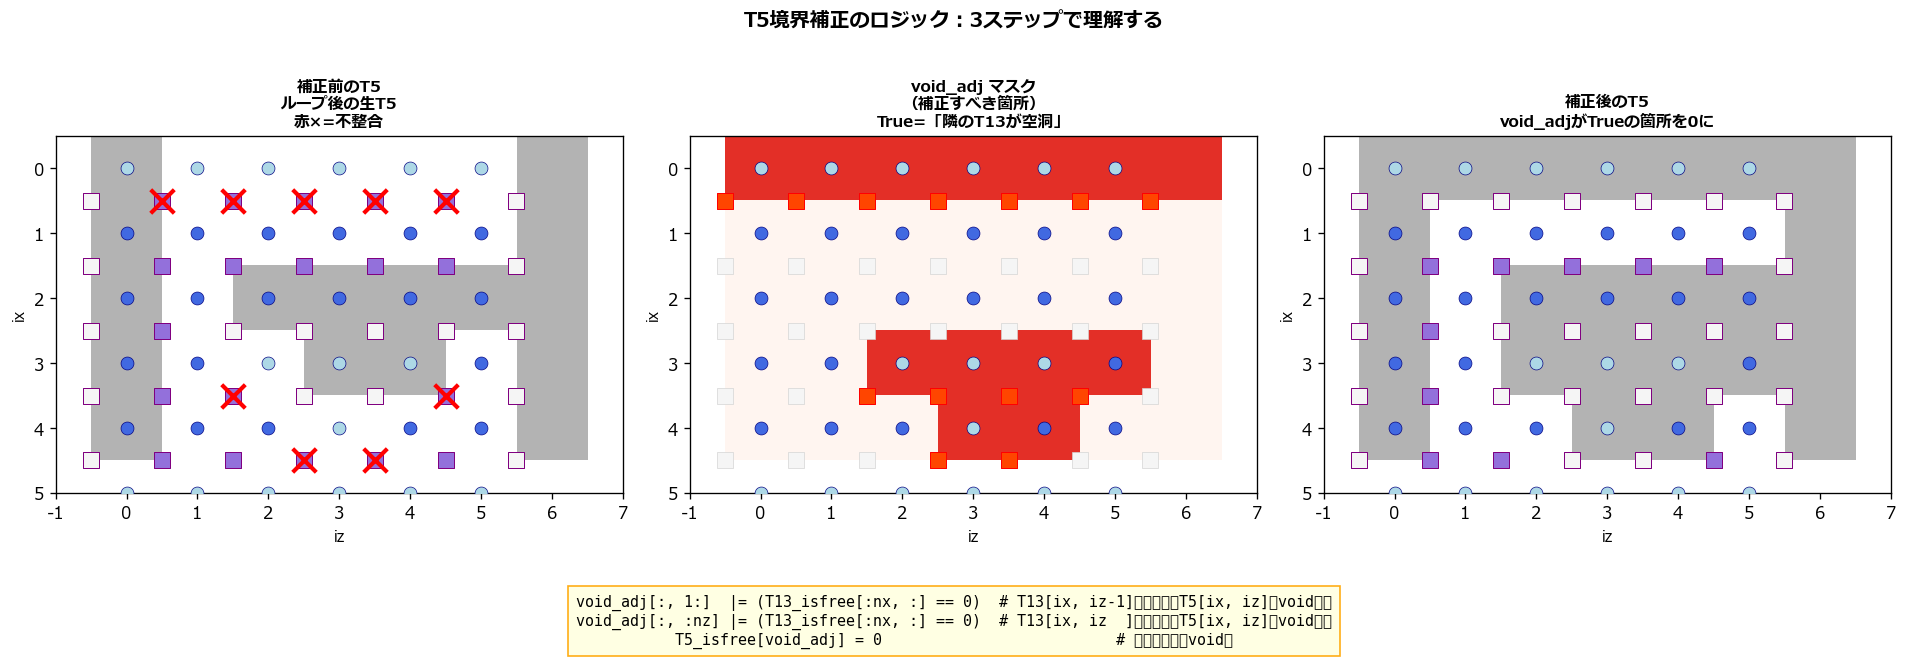

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 小さな例で補正ロジックを1行ずつ可視化
NX_ex, NZ_ex = 5, 6

# 手動で「不整合が起きやすい」T13を作成
T13_ex = np.ones((NX_ex+1, NZ_ex))
T13_ex[0, :] = 0; T13_ex[NX_ex, :] = 0
# 穴: ix=3,4 の iz=2,3,4 を空洞
T13_ex[3, 2:5] = 0
T13_ex[4, 2:5] = 0
# 半円部: ix=4 の iz=3 のみ
T13_ex[4, 2] = 1
T13_ex[4, 4] = 1

# T5 補正前（ループ段階でT5を一部だけ設定）
T5_ex = np.ones((NX_ex, NZ_ex+1))
T5_ex[:, 0] = 0; T5_ex[:, NZ_ex] = 0
T5_ex[2, 2:6] = 0
T5_ex[3, 3:5] = 0  # ← iz=2,5は未設定（不整合）

# void_adj 計算
void_adj = np.zeros((NX_ex, NZ_ex+1), dtype=bool)
void_adj[:, 1:]  |= (T13_ex[:NX_ex, :] == 0)   # step A
void_adj_A = void_adj.copy()
void_adj[:, :NZ_ex] |= (T13_ex[:NX_ex, :] == 0)  # step B
void_adj_AB = void_adj.copy()

T5_corrected = T5_ex.copy()
T5_corrected[void_adj] = 0

for ax, arr, title, cmap, note in [
    (axes[0], T5_ex,       '補正前のT5', 'PuBu', 'ループ後の生T5\n赤×=不整合'),
    (axes[1], void_adj_AB, 'void_adj マスク\n（補正すべき箇所）', 'Oranges',
     'True=「隣のT13が空洞」'),
    (axes[2], T5_corrected,'補正後のT5', 'PuBu', 'void_adjがTrueの箇所を0に'),
]:
    disp_arr = arr.astype(float) if arr.dtype == bool else (1 - arr)  # solidを明るく
    if arr.dtype == bool:
        im = ax.imshow(disp_arr, cmap='Reds', vmin=0, vmax=1.5, aspect='auto',
                       extent=[-0.5, NZ_ex+0.5, NX_ex-0.5, -0.5], origin='upper')
    else:
        im = ax.imshow(disp_arr, cmap='Greys', vmin=0, vmax=1.5, aspect='auto',
                       extent=[-0.5, NZ_ex+0.5, NX_ex-0.5, -0.5], origin='upper', alpha=0.5)

    # T13 背景（青系）
    for ix in range(NX_ex+1):
        for iz in range(NZ_ex):
            c = 'royalblue' if T13_ex[ix, iz] == 1 else 'lightblue'
            ax.scatter(iz, ix, s=60, c=c, marker='o', zorder=3, edgecolors='navy', lw=0.4)

    # T5
    if arr.dtype != bool:
        for ix in range(NX_ex):
            for iz in range(NZ_ex+1):
                c = 'mediumpurple' if arr[ix, iz] == 1 else 'whitesmoke'
                ax.scatter(iz - 0.5, ix + 0.5, s=90, c=c, marker='s', zorder=4,
                           edgecolors='purple', lw=0.6)
        if title.startswith('補正前'):
            # 不整合を×で示す
            inco = np.zeros((NX_ex, NZ_ex+1), dtype=bool)
            inco[:, 1:]  |= (T13_ex[:NX_ex, :] == 0)
            inco[:, :NZ_ex] |= (T13_ex[:NX_ex, :] == 0)
            inco &= (T5_ex == 1)
            ixs, izs = np.where(inco)
            for ix, iz in zip(ixs, izs):
                ax.scatter(iz - 0.5, ix + 0.5, s=200, c='red', marker='x', zorder=5, lw=2.5)
    else:
        for ix in range(NX_ex):
            for iz in range(NZ_ex+1):
                if arr[ix, iz]:
                    ax.scatter(iz - 0.5, ix + 0.5, s=90, c='orangered', marker='s', zorder=4,
                               edgecolors='red', lw=0.6)
                else:
                    ax.scatter(iz - 0.5, ix + 0.5, s=90, c='whitesmoke', marker='s', zorder=4,
                               edgecolors='lightgray', lw=0.4)

    ax.set_xlim(-1, NZ_ex + 1)
    ax.set_ylim(NX_ex, -0.5)
    ax.set_xlabel('iz', fontsize=9)
    ax.set_ylabel('ix', fontsize=9)
    ax.set_title(f'{title}\n{note}', fontsize=9.5, fontweight='bold')

# コード注釈
fig.text(0.5, -0.06,
    "void_adj[:, 1:]  |= (T13_isfree[:nx, :] == 0)  # T13[ix, iz-1]が空洞ならT5[ix, iz]もvoid候補\n"
    "void_adj[:, :nz] |= (T13_isfree[:nx, :] == 0)  # T13[ix, iz  ]が空洞ならT5[ix, iz]もvoid候補\n"
    "T5_isfree[void_adj] = 0                          # 候補を一括でvoidに",
    ha='center', va='top', fontsize=9, family='monospace',
    bbox=dict(fc='lightyellow', ec='orange', alpha=0.9, pad=5))

plt.suptitle('T5境界補正のロジック：3ステップで理解する', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. まとめ：kusabi vs ushapeの違いを一覧で確認

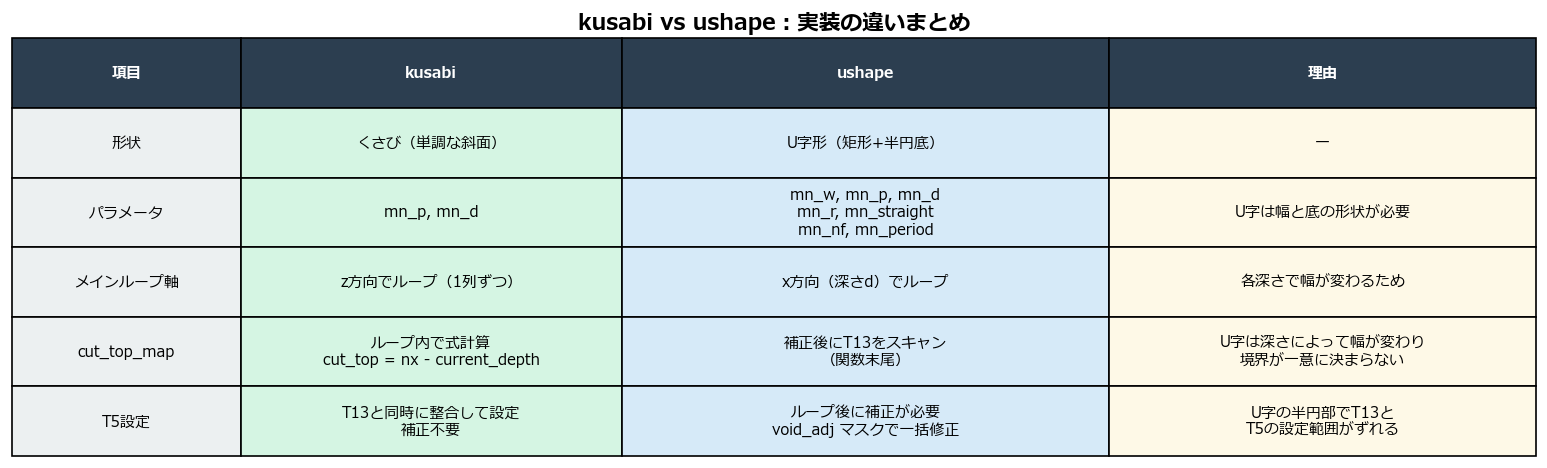

In [13]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

table_data = [
    ['項目', 'kusabi', 'ushape', '理由'],
    ['形状', 'くさび（単調な斜面）', 'U字形（矩形+半円底）', '—'],
    ['パラメータ', 'mn_p, mn_d', 'mn_w, mn_p, mn_d\nmn_r, mn_straight\nmn_nf, mn_period', 'U字は幅と底の形状が必要'],
    ['メインループ軸', 'z方向でループ（1列ずつ）', 'x方向（深さd）でループ', '各深さで幅が変わるため'],
    ['cut_top_map', 'ループ内で式計算\ncut_top = nx - current_depth', '補正後にT13をスキャン\n（関数末尾）', 'U字は深さによって幅が変わり\n境界が一意に決まらない'],
    ['T5設定', 'T13と同時に整合して設定\n補正不要', 'ループ後に補正が必要\nvoid_adj マスクで一括修正', 'U字の半円部でT13と\nT5の設定範囲がずれる'],
]

colors = [['#2c3e50']*4,
          ['#ecf0f1','#d5f5e3','#d6eaf8','#fef9e7'],
          ['#ecf0f1','#d5f5e3','#d6eaf8','#fef9e7'],
          ['#ecf0f1','#d5f5e3','#d6eaf8','#fef9e7'],
          ['#ecf0f1','#d5f5e3','#d6eaf8','#fef9e7'],
          ['#ecf0f1','#d5f5e3','#d6eaf8','#fef9e7']]

tbl = ax.table(cellText=table_data, cellLoc='center', loc='center',
               cellColours=colors,
               colWidths=[0.15, 0.25, 0.32, 0.28])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 3.2)

# ヘッダ文字色
for j in range(4):
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

ax.set_title('kusabi vs ushape：実装の違いまとめ', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## 補足：実際のパラメータでの全体像確認

In [14]:
# 実際のシミュレーションパラメータ（スケールダウン版）
mesh_length = 1.0e-5

f_pitch = 1.25e-3; f_depth_k = 0.20e-3; step_k = 1
f_width_u = 0.25e-3; f_depth_u = 0.20e-3; step_u = 1

mn_p_real = int(round(f_pitch / mesh_length))        # 125
mn_d_k_real = int(round(f_depth_k / mesh_length))   # 20
mn_w_real = int(round(f_width_u / mesh_length))      # 25
if mn_w_real % 2 == 0: mn_w_real -= 1               # 25 (奇数)
mn_d_u_real = int(round(f_depth_u / mesh_length))   # 20
mn_r_real = mn_w_real // 2                           # 12
mn_straight_real = mn_d_u_real - mn_r_real           # 8
mn_nf_real = max(0, mn_p_real - 2*mn_w_real)        # 75
mn_period_real = mn_w_real + mn_nf_real              # 100

print('=== 実際のパラメータ（mesh_length=1e-5 m）===')
print()
print('[kusabi]')
print(f'  mn_p   = {mn_p_real}  （1ピッチ = {f_pitch*1000:.2f} mm）')
print(f'  mn_d   = {mn_d_k_real}   （深さ = {f_depth_k*1000:.2f} mm）')
print(f'  step   = {step_k}')
print()
print('[ushape]')
print(f'  mn_w        = {mn_w_real}   （幅 = {f_width_u*1000:.2f} mm → 奇数調整済）')
print(f'  mn_d        = {mn_d_u_real}   （深さ = {f_depth_u*1000:.2f} mm）')
print(f'  mn_r        = {mn_r_real}   （半円半径 = mn_w//2）')
print(f'  mn_straight = {mn_straight_real}    （矩形部高さ = mn_d - mn_r）')
print(f'  mn_p        = {mn_p_real}  （ピッチ = {f_pitch*1000:.2f} mm）')
print(f'  mn_nf       = {mn_nf_real}   （隙間 = mn_p - 2×mn_w）')
print(f'  mn_period   = {mn_period_real}  （繰り返し周期 = mn_w + mn_nf）')

=== 実際のパラメータ（mesh_length=1e-5 m）===

[kusabi]
  mn_p   = 125  （1ピッチ = 1.25 mm）
  mn_d   = 20   （深さ = 0.20 mm）
  step   = 1

[ushape]
  mn_w        = 25   （幅 = 0.25 mm → 奇数調整済）
  mn_d        = 20   （深さ = 0.20 mm）
  mn_r        = 12   （半円半径 = mn_w//2）
  mn_straight = 8    （矩形部高さ = mn_d - mn_r）
  mn_p        = 125  （ピッチ = 1.25 mm）
  mn_nf       = 75   （隙間 = mn_p - 2×mn_w）
  mn_period   = 100  （繰り返し周期 = mn_w + mn_nf）
